# 03 — Spá (the forecast)

**What this is.** A bottom-up 12-month forecast of VNV: each of 17 components gets a
transparent m/m model, and the paths are aggregated with the **latest published weights,
price-updated through the horizon** by the engine verified in notebook 02.

**Model per component (v0 — deliberately simple and inspectable)**
- *Default*: estimated monthly seasonal factors + AR(1) on the deseasonalized m/m
  (sample 2016–, spliced COICOP2018 history).
- *Reiknuð húsaleiga (CP042)*: post-June-2024 sample only (methodology break), persistence
  model — rents under rental equivalence are slow-moving stock rents.
- Divisions restructured by COICOP2018 (07–10, 12, 13) borrow seasonal/AR parameters from
  their old-classification analogues, **for parameter fitting only** — flagged in
  `models.OLD_PROXY`.

**What v0 does *not* yet include** (Phases 3–6 of the plan): scraped airfares/fuel/grocery
nowcasts, the fiscal & wage calendars, HMS rent pass-through, top-down reconciliation
(MinT). Those mostly sharpen h=1–3. The backtest below is honest about the consequence.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.0f}")

# Okabe-Ito palette (colorblind-safe); recessive grid per house chart style
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "red": "#D55E00", "pink": "#CC79A7", "sky": "#56B4E9", "black": "#222222"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


In [2]:
from vnv import ingest, models

head = ingest.load_headline()
sub_new = ingest.load_sub_new()
panel_old = ingest.load_panel_old()
spliced = ingest.load_sub_spliced()
vt = ingest.load_verdtrygging()

g = models.build_component_history(spliced, panel_old, sub_new)
last_m = g.index.max()
latest = sub_new[sub_new.manudur == last_m].set_index("code")
w0 = latest.loc[models.COMPONENTS, "vaegi"]
print(f"jump-off: {last_m}   component weight sum: {w0.sum():.2f}")


jump-off: 2026-07   component weight sum: 100.01


## Component models — every parameter visible

In [3]:
fits = {c: models.fit_component(g[c], c) for c in models.COMPONENTS}
param_tbl = pd.DataFrame({
    "heiti": latest.loc[models.COMPONENTS, "heiti"].str.slice(0, 44),
    "vægi (%)": w0,
    "AR(1) φ": [fits[c].phi for c in models.COMPONENTS],
    "resid SD (pp)": [fits[c].resid.std() for c in models.COMPONENTS],
    "n obs": [fits[c].n_obs for c in models.COMPONENTS],
    "note": [fits[c].note for c in models.COMPONENTS],
})
param_tbl.round(3)


,heiti,vægi (%),AR(1) φ,resid SD (pp),n obs,note
code,,,,,,
CP01,01 Matur og óáfengir drykkir,15.2500,0.3590,0.5160,127,
CP02,"02 Áfengir drykkir, tóbak og fíkniefni",2.4700,0.0200,0.4620,127,
CP03,03 Fatnaður og skófatnaður,3.2900,-0.2980,1.7310,127,
CP041,041 Greidd húsaleiga,3.6300,0.2120,0.3780,127,
CP042,042 Reiknuð húsaleiga,20.7400,0.7000,0.3540,25,post-2024-07 sample only (methodology break)
CP043,"043 Viðhald, viðgerðir og öryggi húsnæðis",1.0700,0.1320,0.5520,127,
CP044,044 Vatnsveita og ýmis þjónusta tengd húsnæð,1.6500,-0.3030,1.1300,127,
CP045,"045 Rafmagn, gas og aðrir orkugjafar",2.9800,-0.1570,0.7310,127,
CP05,"05 Húsbúnaður, heimilistæki og þjónusta teng",3.9000,-0.2240,1.1200,127,


In [4]:
# Seasonal factors per component (pp per month) - the deterministic core of the forecast
seas_tbl = pd.DataFrame({c: fits[c].seasonal for c in models.COMPONENTS}).T
seas_tbl.columns = ["jan", "feb", "mar", "apr", "maí", "jún", "júl", "ágú", "sep", "okt", "nóv", "des"]
seas_tbl.round(2)


,jan,feb,mar,apr,maí,jún,júl,ágú,sep,okt,nóv,des
CP01,0.7700,0.4600,0.2500,0.5300,0.5100,0.1900,0.2600,0.2500,0.1200,0.7100,0.1200,0.1600
CP02,2.5100,0.6100,-0.0100,0.0900,0.2300,0.1500,0.0200,0.1700,0.0200,0.0200,0.0300,0.0800
CP03,-9.2300,4.4200,4.3500,0.2800,0.0600,0.6500,-7.7100,3.6300,4.5600,0.6500,-0.4100,0.8400
CP041,0.1700,0.6800,0.5600,0.4300,0.5800,0.4800,0.5300,0.4900,0.4900,0.4400,0.5900,0.4600
CP042,0.5500,0.5500,0.5500,0.5500,0.5500,0.5500,0.5500,0.5500,0.5500,0.5500,0.5500,0.5500
CP043,0.2200,0.6500,0.2600,0.5400,0.4000,0.7200,0.2200,0.4400,0.1200,0.4300,0.2200,0.3600
CP044,3.1300,1.5800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
CP045,2.3700,0.1400,0.0400,-0.0400,0.0800,0.0400,0.7800,0.5100,0.1100,0.0500,0.1900,0.5900
CP05,-5.2000,6.0300,-0.4300,0.2000,0.1900,-0.5600,-1.7800,1.1100,1.2800,0.5600,0.2400,0.2100
CP06,0.2900,0.3800,0.5300,0.3100,0.1900,0.1400,0.3600,0.2800,-0.1600,0.2700,0.2800,0.4100


## The 12-month path

The aggregation below is the answer to *“show the weights used to predict the CPI”*:
each month's headline forecast is exactly `Σ weight × component m/m`, with the weight
path shown explicitly.


In [5]:
fc = pd.DataFrame({c: models.forecast_component(fits[c], last_m, 12) for c in models.COMPONENTS})
head_mm, contribs, wpath = models.aggregate_bottom_up(fc, w0)

path = pd.DataFrame({"headline m/m (%)": head_mm})
path["index (spá)"] = head[("CPI", "index")].iloc[-1] * (1 + head_mm / 100).cumprod()
idx_hist = head[("CPI", "index")]
path["y/y (%)"] = (path["index (spá)"] / idx_hist.reindex(path.index - 12).to_numpy() - 1) * 100
print(f"implied 12m inflation to {path.index[-1]}: "
      f"{((1 + head_mm / 100).prod() - 1) * 100:.2f}%")
path.round(2)


implied 12m inflation to 2027-07: 3.90%


,headline m/m (%),index (spá),y/y (%)
2026-08,0.2200,694.7100,5.6400
2026-09,0.1200,695.5300,5.6500
2026-10,0.3700,698.1300,5.5500
2026-11,0.0100,698.1700,6.0700
2026-12,0.4800,701.5300,5.3700
2027-01,-0.0300,701.3300,4.9400
2027-02,0.7600,706.6600,4.7500
2027-03,0.4300,709.7200,4.6300
2027-04,0.5100,713.3300,4.3200
2027-05,0.2800,715.3100,4.5300


In [6]:
# Contribution decomposition: weight x m/m = contribution, month by month (pp)
name_map = latest.loc[models.COMPONENTS, "heiti"].str.slice(0, 40)
contrib_show = contribs.T.set_axis(name_map.reindex(contribs.columns), axis=0)
contrib_show["12m samtals"] = contrib_show.sum(axis=1)
contrib_show.sort_values("12m samtals", ascending=False).round(3)


,2026-08,2026-09,2026-10,2026-11,2026-12,2027-01,2027-02,2027-03,2027-04,2027-05,2027-06,2027-07,12m samtals
heiti,,,,,,,,,,,,,
042 Reiknuð húsaleiga,0.1150,0.1150,0.1150,0.1150,0.1150,0.1150,0.1160,0.1160,0.1160,0.1160,0.1160,0.1160,1.3860
01 Matur og óáfengir drykkir,0.0250,0.0130,0.1070,0.0180,0.0250,0.1170,0.0710,0.0390,0.0810,0.0770,0.0300,0.0410,0.6430
07 Flutningar,-0.1700,-0.2500,0.0800,-0.1400,0.2060,0.0200,0.0060,0.0540,0.2480,-0.0340,0.2090,0.3240,0.5520
11 Veitingahús og gistiþjónusta,0.0220,-0.0390,-0.0270,-0.0030,0.0070,0.0480,0.0310,0.0270,0.0160,0.0450,0.0750,0.0450,0.2470
"09 Afþreying, íþróttir og menning",0.0080,0.0540,0.0340,0.0160,0.0080,-0.0060,0.0780,-0.0030,0.0020,0.0290,0.0230,-0.0050,0.2380
041 Greidd húsaleiga,0.0170,0.0180,0.0160,0.0220,0.0170,0.0060,0.0250,0.0200,0.0160,0.0210,0.0180,0.0200,0.2160
"045 Rafmagn, gas og aðrir orkugjafar",0.0170,0.0030,0.0020,0.0060,0.0180,0.0710,0.0040,0.0010,-0.0010,0.0020,0.0010,0.0230,0.1470
"13 Persónuleg umhirða, félagsþjónusta og",0.0230,0.0030,0.0130,0.0020,0.0250,0.0220,0.0110,0.0150,0.0070,-0.0000,0.0260,-0.0040,0.1410
06 Heilsa,0.0110,-0.0060,0.0110,0.0110,0.0160,0.0120,0.0150,0.0210,0.0120,0.0070,0.0050,0.0140,0.1290


In [7]:
# The weight path used at each forecast month (price-updated from the latest published Vaegi)
wpath.T.set_axis(name_map.reindex(wpath.columns), axis=0).round(2)


,2026-08,2026-09,2026-10,2026-11,2026-12,2027-01,2027-02,2027-03,2027-04,2027-05,2027-06,2027-07
heiti,,,,,,,,,,,,
01 Matur og óáfengir drykkir,15.2500,15.2400,15.2400,15.2900,15.3000,15.2500,15.3700,15.3300,15.3000,15.3000,15.3400,15.3000
"02 Áfengir drykkir, tóbak og fíkniefni",2.4700,2.4700,2.4700,2.4600,2.4600,2.4500,2.5100,2.5100,2.5000,2.4900,2.4800,2.4800
03 Fatnaður og skófatnaður,3.2900,3.3700,3.5300,3.5400,3.5200,3.5400,3.2100,3.3300,3.4600,3.4500,3.4400,3.4500
041 Greidd húsaleiga,3.6300,3.6400,3.6500,3.6500,3.6800,3.6800,3.6800,3.6800,3.6800,3.6800,3.6900,3.6900
042 Reiknuð húsaleiga,20.7400,20.8100,20.9000,20.9300,21.0500,21.0600,21.1800,21.1400,21.1600,21.1700,21.2300,21.2400
"043 Viðhald, viðgerðir og öryggi húsnæði",1.0700,1.0700,1.0700,1.0700,1.0800,1.0700,1.0800,1.0800,1.0700,1.0700,1.0800,1.0800
044 Vatnsveita og ýmis þjónusta tengd hú,1.6500,1.6500,1.6400,1.6400,1.6400,1.6300,1.6800,1.7000,1.6900,1.6800,1.6800,1.6700
"045 Rafmagn, gas og aðrir orkugjafar",2.9800,2.9900,2.9900,2.9800,2.9900,2.9900,3.0600,3.0400,3.0300,3.0100,3.0100,2.9900
"05 Húsbúnaður, heimilistæki og þjónusta",3.9000,3.9400,3.9800,3.9900,4.0000,3.9900,3.7800,3.9800,3.9500,3.9400,3.9300,3.8900


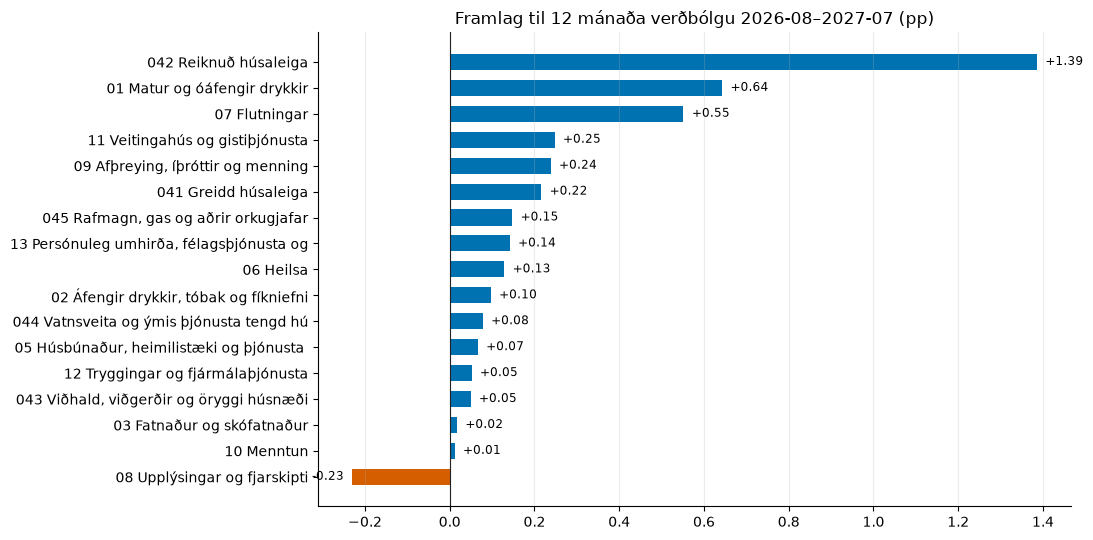

In [8]:
first, last12 = contribs.index[0], contribs.sum()
d = last12.sort_values()
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(name_map.reindex(d.index), d, color=[C["red"] if v < 0 else C["blue"] for v in d], height=0.62)
for i, v in enumerate(d):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5)
ax.axvline(0, color=C["black"], lw=0.8)
ax.set_title(f"Framlag til 12 mánaða verðbólgu {path.index[0]}–{path.index[-1]} (pp)")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()


## Uncertainty — bootstrap fan chart (joint residual months, cross-correlation preserved)

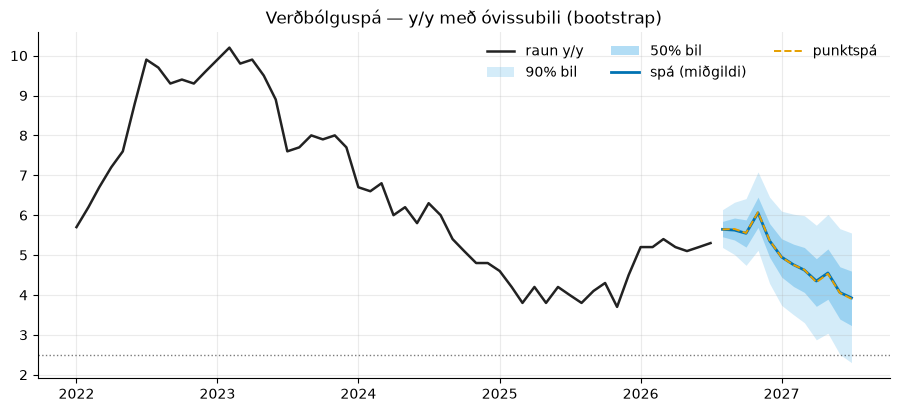

In [9]:
sims = models.bootstrap_paths(fits, fc, w0, n_sims=2000)
idx0 = float(idx_hist.iloc[-1])
lvl_sims = idx0 * (1 + sims / 100).cumprod(axis=1)
base = idx_hist.reindex(sims.columns - 12).to_numpy()
yy_sims = (lvl_sims / base - 1) * 100

qs = yy_sims.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T
hist_yy = head[("CPI", "change_A")]["2022":]
fig, ax = plt.subplots()
ax.plot(hist_yy.index.to_timestamp(), hist_yy, color=C["black"], lw=1.8, label="raun y/y")
x = qs.index.to_timestamp()
ax.fill_between(x, qs[0.05], qs[0.95], color=C["sky"], alpha=0.25, lw=0, label="90% bil")
ax.fill_between(x, qs[0.25], qs[0.75], color=C["sky"], alpha=0.45, lw=0, label="50% bil")
ax.plot(x, qs[0.5], color=C["blue"], lw=2, label="spá (miðgildi)")
ax.plot(path.index.to_timestamp(), path["y/y (%)"], color=C["orange"], lw=1.4, ls="--", label="punktspá")
ax.axhline(2.5, color=C["black"], lw=1, ls=":", alpha=0.6)
ax.set_title("Verðbólguspá — y/y með óvissubili (bootstrap)")
ax.legend(frameon=False, ncols=3)
plt.show()


## Verðtrygging path

VNV published for month $t$ sets the indexation base for month $t+2$; the fund's indexed
instruments settle on `VIS01004`. The first two rows below are therefore already **known**
from published prints — the model only matters from the third row on.


In [10]:
# empirical t+2 mapping check on published data
vt_s = vt["financial_indexation"].dropna()
cpi_s = idx_hist.dropna()
check = pd.DataFrame({"verðtrygging(t+2)": vt_s.reindex(cpi_s.index + 2).to_numpy(),
                      "VNV(t)": cpi_s.to_numpy()}, index=cpi_s.index).dropna().tail(6)
check["hlutfall"] = check.iloc[:, 0] / check.iloc[:, 1]
assert (check.hlutfall.round(4) == 1).all(), "t+2 mapping does not hold"
print("verified: verðtrygging index in t+2 equals published VNV of month t\n")

vt_path = pd.DataFrame({"VNV": path["index (spá)"].round(1)})
vt_path.index = path.index + 2
vt_path.index.name = "verðtryggingarmánuður"
vt_path["m/m verðbóta (%)"] = (vt_path.VNV / pd.concat([idx_hist.tail(2), path["index (spá)"]]).round(1).shift(1).reindex(path.index).to_numpy() - 1) * 100
vt_path.round(2)


verified: verðtrygging index in t+2 equals published VNV of month t



,VNV,m/m verðbóta (%)
verðtryggingarmánuður,,
2026-10,694.7000,0.2200
2026-11,695.5000,0.1200
2026-12,698.1000,0.3700
2027-01,698.2000,0.0100
2027-02,701.5000,0.4700
2027-03,701.3000,-0.0300
2027-04,706.7000,0.7700
2027-05,709.7000,0.4200
2027-06,713.3000,0.5100


## Honest backtest — walk-forward h=1, model vs floors

Refitted each month on data through $t-1$, aggregated with the *published* weights of
$t-1$ (no look-ahead). Actual = the published headline m/m from `VIS01000`.


In [11]:
test_months = [m for m in g.index if m > pd.Period("2025-01", "M") and m <= last_m]
rows = []
for m in test_months:
    g_tr = g[g.index < m]
    w_prev = sub_new[(sub_new.manudur == m - 1) & sub_new.code.isin(models.COMPONENTS)]
    w_prev = w_prev.set_index("code").vaegi
    f = {c: models.forecast_component(models.fit_component(g_tr[c], c), m - 1, 1).iloc[0]
         for c in models.COMPONENTS}
    hm, _, _ = models.aggregate_bottom_up(pd.DataFrame([f], index=[m]), w_prev)
    seas = {c: g_tr[c][(g_tr.index.month == m.month) & (g_tr.index >= "2016-01")].mean()
            for c in models.COMPONENTS}
    hs, _, _ = models.aggregate_bottom_up(pd.DataFrame([seas], index=[m]), w_prev)
    rows.append({"manudur": m, "model": hm.iloc[0], "seasonal naive": hs.iloc[0],
                 "random walk": float(g.loc[m - 1] @ (w_prev / w_prev.sum())),
                 "actual": head[("CPI", "change_M")].get(m, np.nan)})
bt = pd.DataFrame(rows).set_index("manudur").dropna()

stats = pd.DataFrame({
    c: {"RMSE (pp)": np.sqrt(((bt[c] - bt.actual) ** 2).mean()),
        "MAE (pp)": (bt[c] - bt.actual).abs().mean()}
    for c in ["model", "seasonal naive", "random walk"]
}).T
display(bt.round(3))
stats.round(3)


,model,seasonal naive,random walk,actual
manudur,,,,
2025-02,0.6430,0.8240,-0.1500,0.9100
2025-03,0.4920,0.5380,0.9250,0.3700
2025-04,0.4840,0.6250,0.3500,0.9300
2025-05,0.4350,0.3940,0.8600,0.2000
2025-06,0.4100,0.4930,0.2080,0.8400
2025-07,0.2120,0.1940,0.8150,0.3200
2025-08,0.2020,0.2940,0.2750,-0.1500
2025-09,0.1170,0.2100,-0.0430,0.1100
2025-10,0.4680,0.4490,0.1890,0.4700


,RMSE (pp),MAE (pp)
model,0.3610,0.2930
seasonal naive,0.3400,0.2720
random walk,0.7090,0.6340


**Read this honestly.** Over the 18-month window the v0 model roughly matches the
seasonal-naive floor and clearly beats the random walk — it does **not** yet add value
at h=1, exactly as `PLAN_1.md` anticipates: the h=1 misses are dominated by airfares,
útsölur (Jan/Feb sales) and one-off administered steps, which are *observable* (Phase 3
scrapers, fiscal calendar), not forecastable from history. Do not tune this away.

The economic use case is h=3–12, where the fan chart above is compared against breakeven
inflation (RIKS vs RIKB) — that comparison needs Seðlabanki market data (Phase 6/7).

### Next steps per the plan
1. **Phase 3**: airfare & fuel scrapers matched to the collection window; fiscal calendar.
2. **Phase 4**: HMS leiguvísitala → CP042 distributed-lag map (vintage-aware).
3. **Phase 5**: FX/wage ARDL blocks; wage calendar as dated steps.
4. **Phase 6**: BVAR top-down + MinT reconciliation; fan chart from reconciled covariance.
5. **Phase 7**: analyst/Seðlabanki/breakeven benchmark table.
